In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters import threshold_niblack, threshold_sauvola
import os

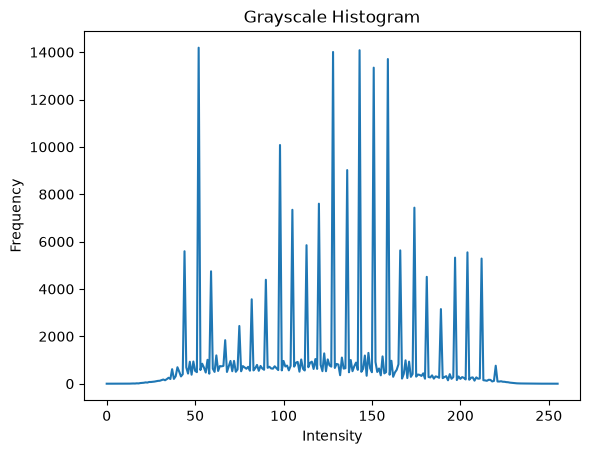

In [8]:
image = cv2.imread(r"C:\Users\PC-LAB1\img_processing_lab\images\lena5.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

hist, bins = np.histogram(
    gray.ravel(), bins=256, range=(0, 256)
)

plt.plot(hist)
plt.title("Grayscale Histogram")
plt.xlabel("Intensity")
plt.ylabel("Frequency")
plt.savefig(r"C:\Users\PC-LAB1\img_processing_lab\output\gray_histogram_lena5.png", dpi=300, bbox_inches='tight')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

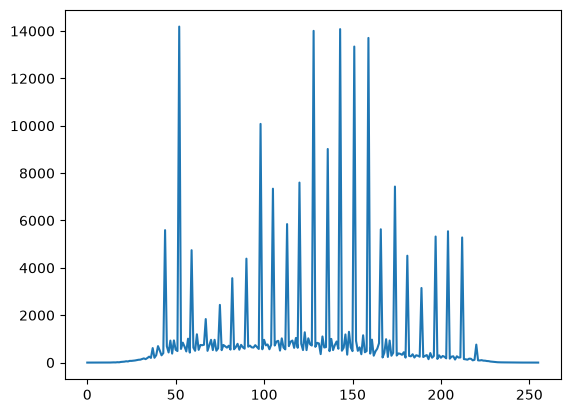

In [3]:
hist = cv2.calcHist(
    [gray], [0], None, [256], [0,256]
)

plt.plot(hist)
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

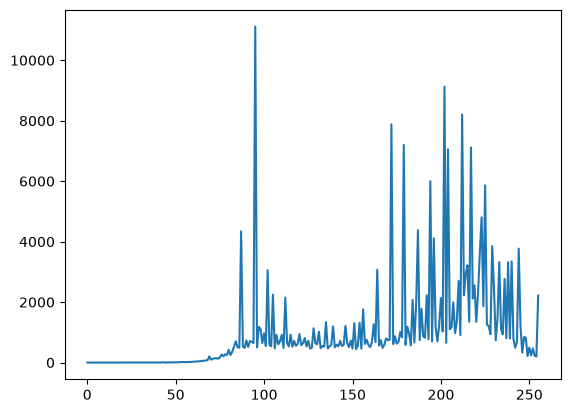

In [6]:
hist = cv2.calcHist(
    [image], [2], None, [256], [0,256]
)

plt.plot(hist)
plt.show

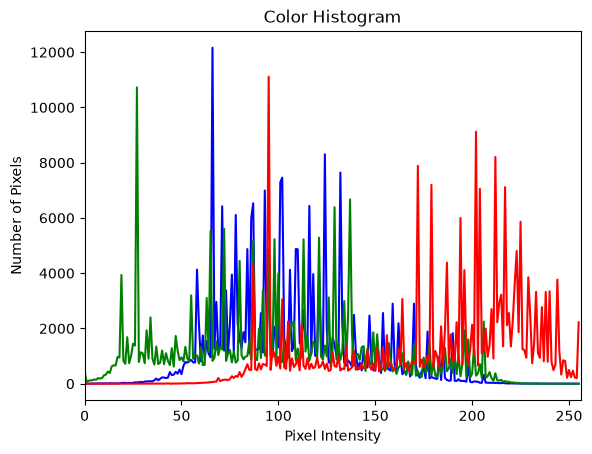

In [9]:
# OpenCV uses BGR, so we define our colors in that order
colors = ('b', 'g', 'r')

for i, color in enumerate(colors):
    # Calculate histogram for the current channel (0, 1, or 2)
    hist = cv2.calcHist([image], [i], None, [256], [0, 256])
    
    # Plot it using the corresponding color
    plt.plot(hist, color=color)
    plt.xlim([0, 256])

plt.title('Color Histogram')
plt.xlabel('Pixel Intensity')
plt.ylabel('Number of Pixels')
plt.savefig(r"C:\Users\PC-LAB1\img_processing_lab\output\color_histogram_lena5.png", dpi=300, bbox_inches='tight')
plt.show()

In [30]:
bright = cv2.convertScaleAbs(
    image, alpha=1.0, beta=40
)

contrast = cv2.convertScaleAbs(
    image, alpha=3.0, beta=-128
)

cv2.imwrite(r"C:\Users\PC-LAB1\img_processing_lab\output\bright_lena5.jpg", bright)
cv2.imwrite(r"C:\Users\PC-LAB1\img_processing_lab\output\contrast_lena5.jpg", contrast)


True

In [33]:
image = cv2.imread(r"C:\Users\PC-LAB1\img_processing_lab\images\image_with_shapes_2.jpeg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [54]:
_, binary = cv2.threshold(
    gray, 210, 255, cv2.THRESH_BINARY
)

cv2.imwrite(r"C:\Users\PC-LAB1\img_processing_lab\output\binary_image_with_shapes_2.png", binary)


True

In [52]:
adaptive = cv2.adaptiveThreshold(
    gray, 255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    7, 2
)

cv2.imwrite(r"C:\Users\PC-LAB1\img_processing_lab\output\adaptive_image_with_shapes_2.png", adaptive)

True

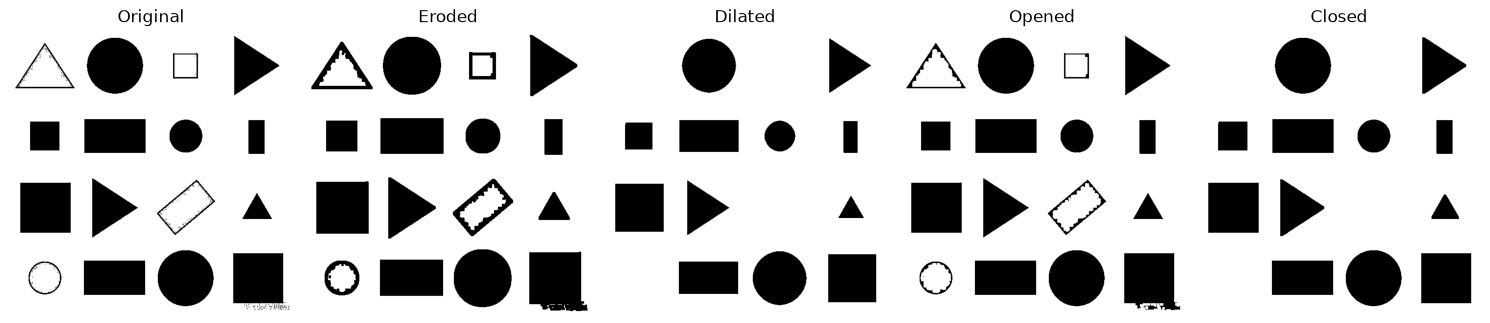

In [55]:
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT, (5, 5)
)

eroded = cv2.erode(
    binary, kernel, iterations=1
)

dilated = cv2.dilate(
    binary, kernel, iterations=1
)

opened = cv2.morphologyEx(
    binary, cv2.MORPH_OPEN, kernel
)

closed = cv2.morphologyEx(
    binary, cv2.MORPH_CLOSE, kernel
)

titles = ['Original', 'Eroded', 'Dilated', 'Opened', 'Closed']
images = [binary, eroded, dilated, opened, closed]

plt.figure(figsize=(15, 4))

for i in range(5):
    plt.subplot(1, 5, i + 1)
    # cmap='gray' is required so binary images don't render as yellow/purple
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis('off')  # Hide axis ticks for a cleaner plot

plt.tight_layout()
plt.show()


In [56]:
image = cv2.imread(r"C:\Users\PC-LAB1\img_processing_lab\images\lena5.jpg")
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

In [57]:
blurred = cv2.GaussianBlur(
    gray, (5, 5), 0
)

edges = cv2.Canny(
    gray, 50, 150
)

edges_smooth = cv2.Canny(
    blurred, 50, 150
)

cv2.imwrite(r"C:\Users\PC-LAB1\img_processing_lab\output\edges_lena5.png", edges)
cv2.imwrite(r"C:\Users\PC-LAB1\img_processing_lab\output\edges_smooth_lena5.png", edges_smooth)



True

In [58]:
def auto_canny(image, sigma=0.33):
    # Compute the median of the single channel pixel intensities
    v = np.median(image)
    
    # Apply automatic Canny edge detection using the computed median
    lower = int(max(0, (1.0 - sigma) * v))
    upper = int(min(255, (1.0 + sigma) * v))
    
    edged = cv2.Canny(image, lower, upper)
    
    return edged

In [59]:
edges_auto = auto_canny(blurred)

cv2.imwrite(r"C:\Users\PC-LAB1\img_processing_lab\output\edges_auto_lena5.png", edges_auto)

True